# Virtual distillation diagnostics for bosonic states

This notebook visualizes how virtual distillation changes noisy bosonic states. For a noisy density matrix $\rho$, the order-$M$ virtual-distilled expectation value of an observable $O$ is

$$
\langle O \rangle_{\mathrm{VD},M} = \frac{\mathrm{Tr}(O\rho^M)}{\mathrm{Tr}(\rho^M)}.
$$

The figures compare the noisy state without distillation to the effective states $\rho^M/\mathrm{Tr}(\rho^M)$ for $M=2,3,4$. The examples include cat-state Wigner functions, parity trajectories, a Fock-state Wigner function, and two-mode N00N characteristic-function maps.

## Imports and shared setup

The setup cell imports the numerical and plotting tools, fixes the shared simulation parameters, and builds the input states used below. The displayed summary reports the Hilbert-space cutoff chosen for each state and the estimated probability weight left in the final few Fock levels.

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from io import BytesIO
from pathlib import Path
from IPython.display import Image, display

from virtual_dist_functions import *

paper_x_values, paper_y_values = paper_wigner_grid(PAPER_PLOT_CONFIG['wigner_extent'])
paper_fock_x_values, paper_fock_y_values = paper_wigner_grid(PAPER_PLOT_CONFIG['fock_wigner_extent'])
states = build_default_paper_states()

states_summary = {name: {'dim': data['dim'], 'tail': data['tail']} for name, data in states.items()}
states_summary


# Set to 0 to show PNG previews in the notebook, or 1 to save PDFs.
SAVE_PDFS = 0
FINAL_PLOTS_DIR = Path('final_plots')


def output_figure(fig, filename, dpi=160):
    if SAVE_PDFS:
        FINAL_PLOTS_DIR.mkdir(parents=True, exist_ok=True)
        output_path = FINAL_PLOTS_DIR / filename
        fig.savefig(output_path, format='pdf', bbox_inches='tight')
        print(f'Saved {output_path}')
    else:
        buffer = BytesIO()
        fig.savefig(buffer, format='png', dpi=dpi, bbox_inches='tight')
        display(Image(data=buffer.getvalue()))


## Cat Wigner grids, 3x3 layout

These figures show Wigner functions reconstructed from displaced-parity measurements. For a phase-space point $\beta$,

$$
W(\beta) = \frac{2}{\pi}\,\mathrm{Tr}\left[D(\beta)(-1)^{\hat n}D^\dagger(\beta)\rho\right].
$$

The cat states are

$$
|C_+(\alpha)\rangle \propto |\alpha\rangle + |-\alpha\rangle,
\qquad
|C_\square(\alpha)\rangle \propto |\alpha\rangle + |-\alpha\rangle + |i\alpha\rangle + |-i\alpha\rangle.
$$

Each grid shows `Pure state`, `No VD`, `VD M=2`, `VD M=3`, `VD M=4`, and a phase-space $L^2$ error curve to the pure-state Wigner function.

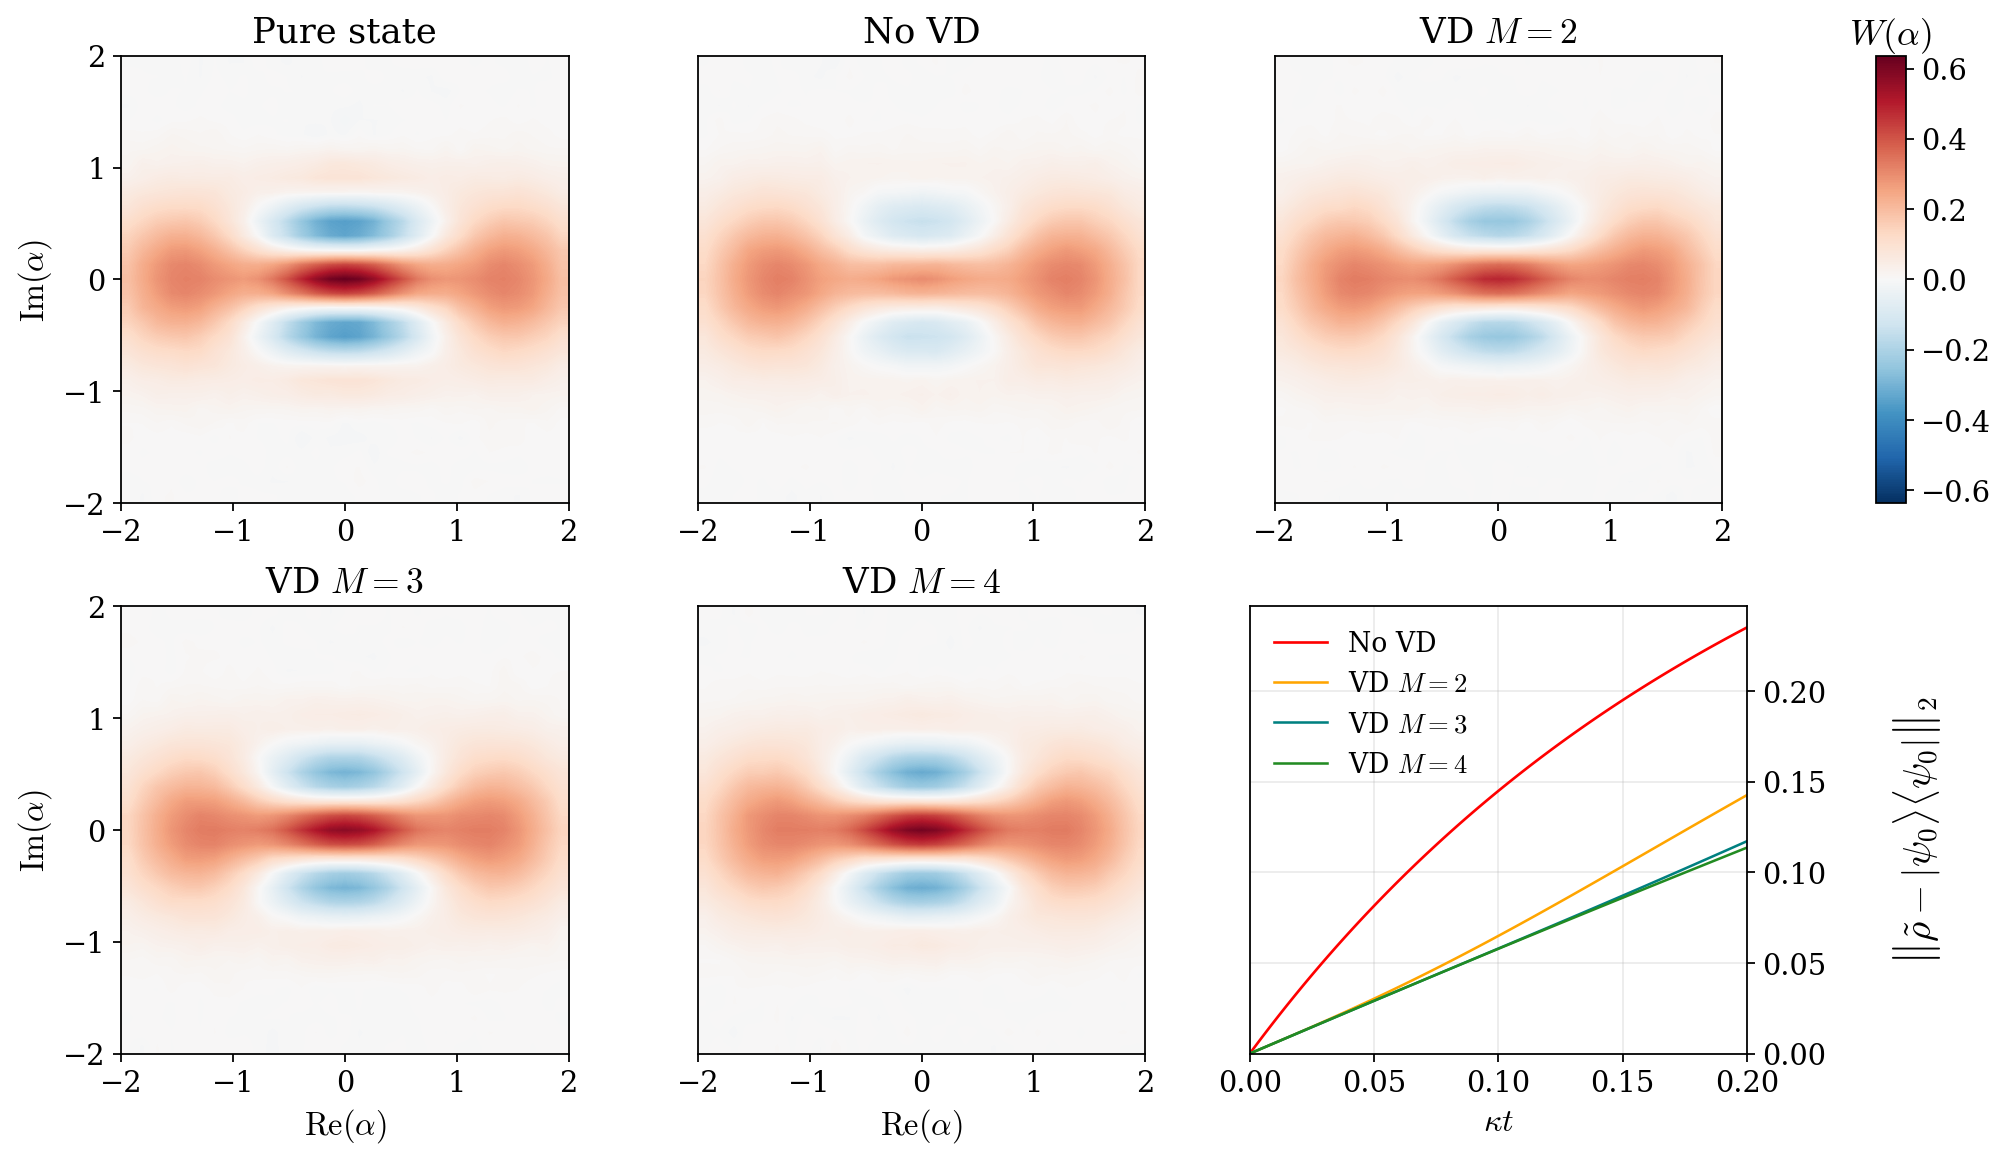

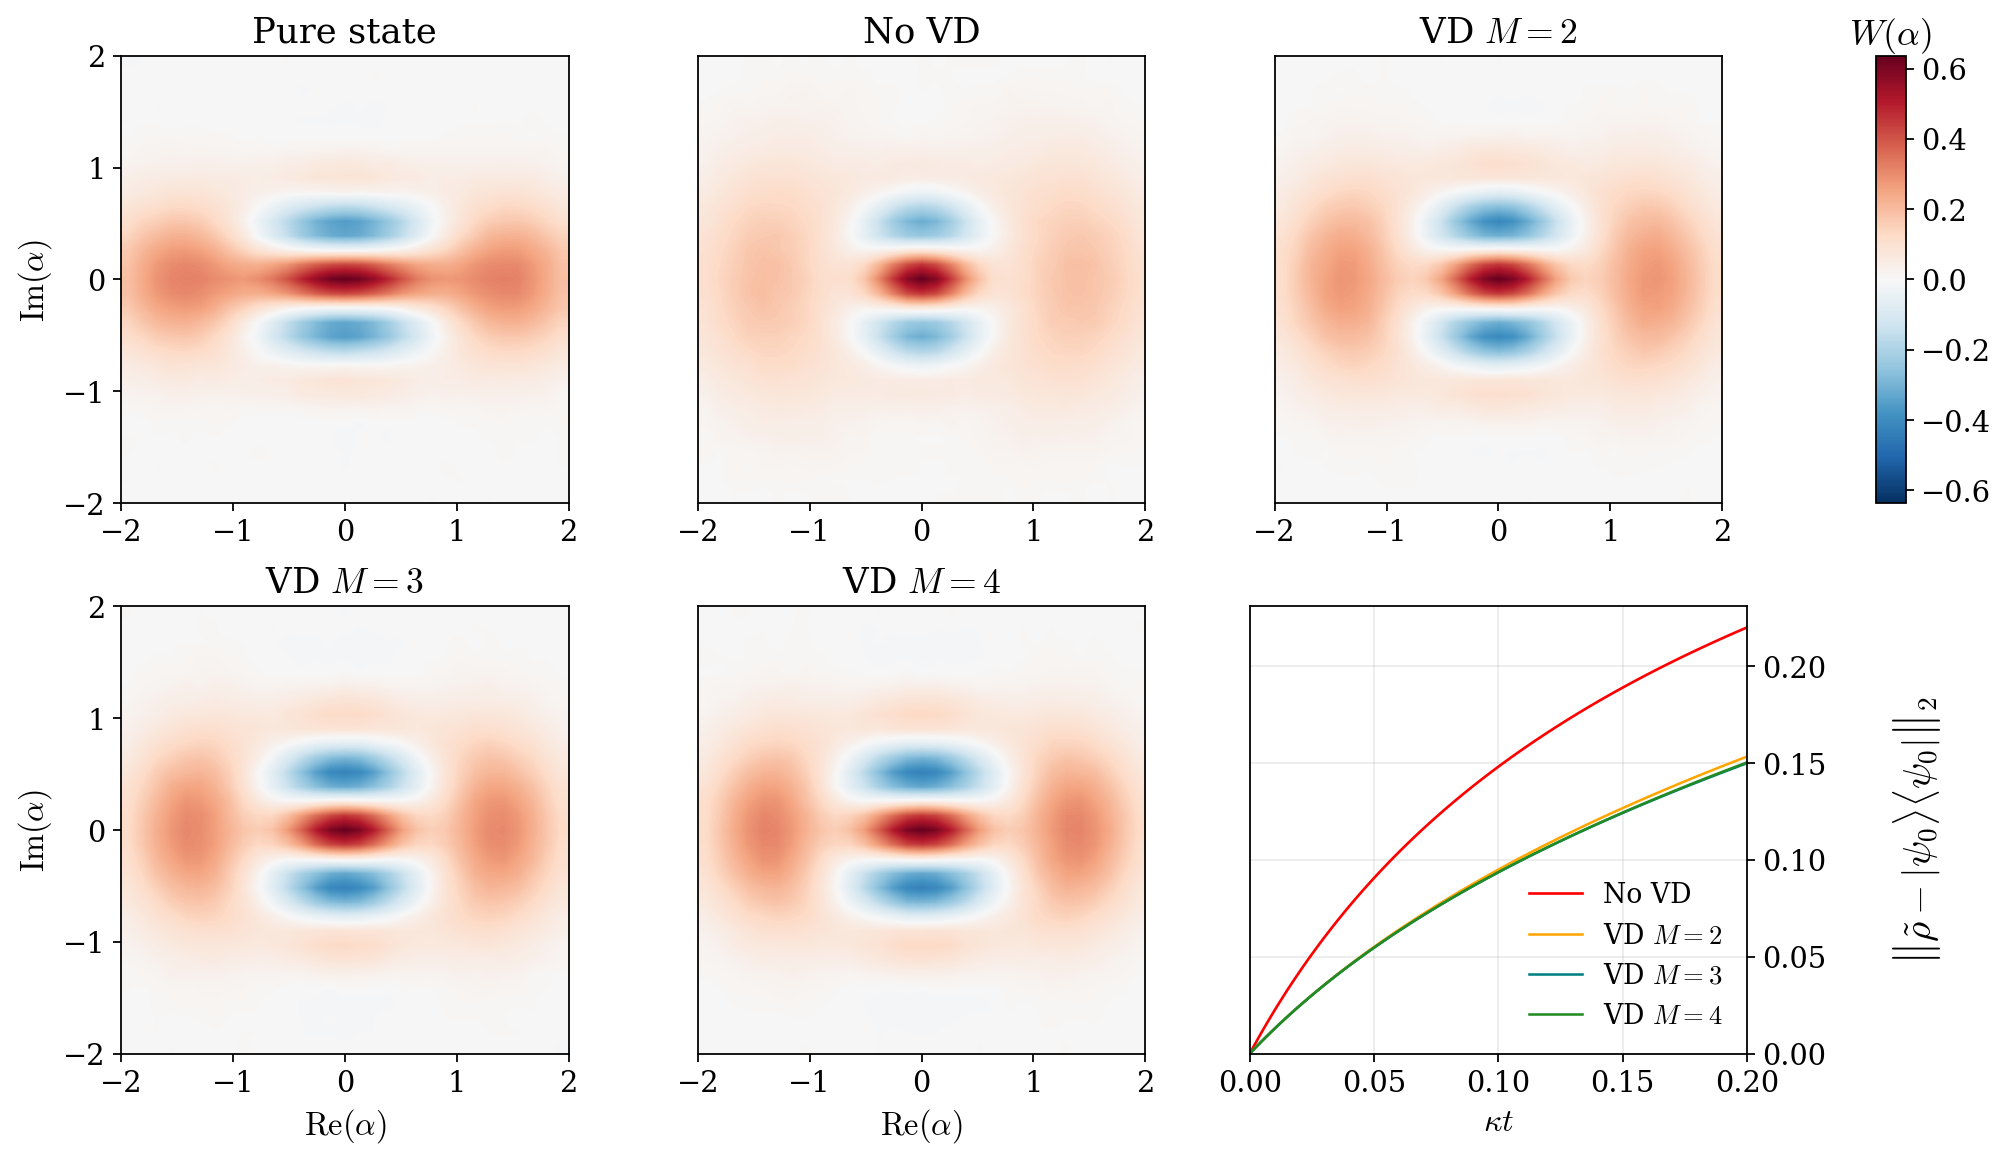

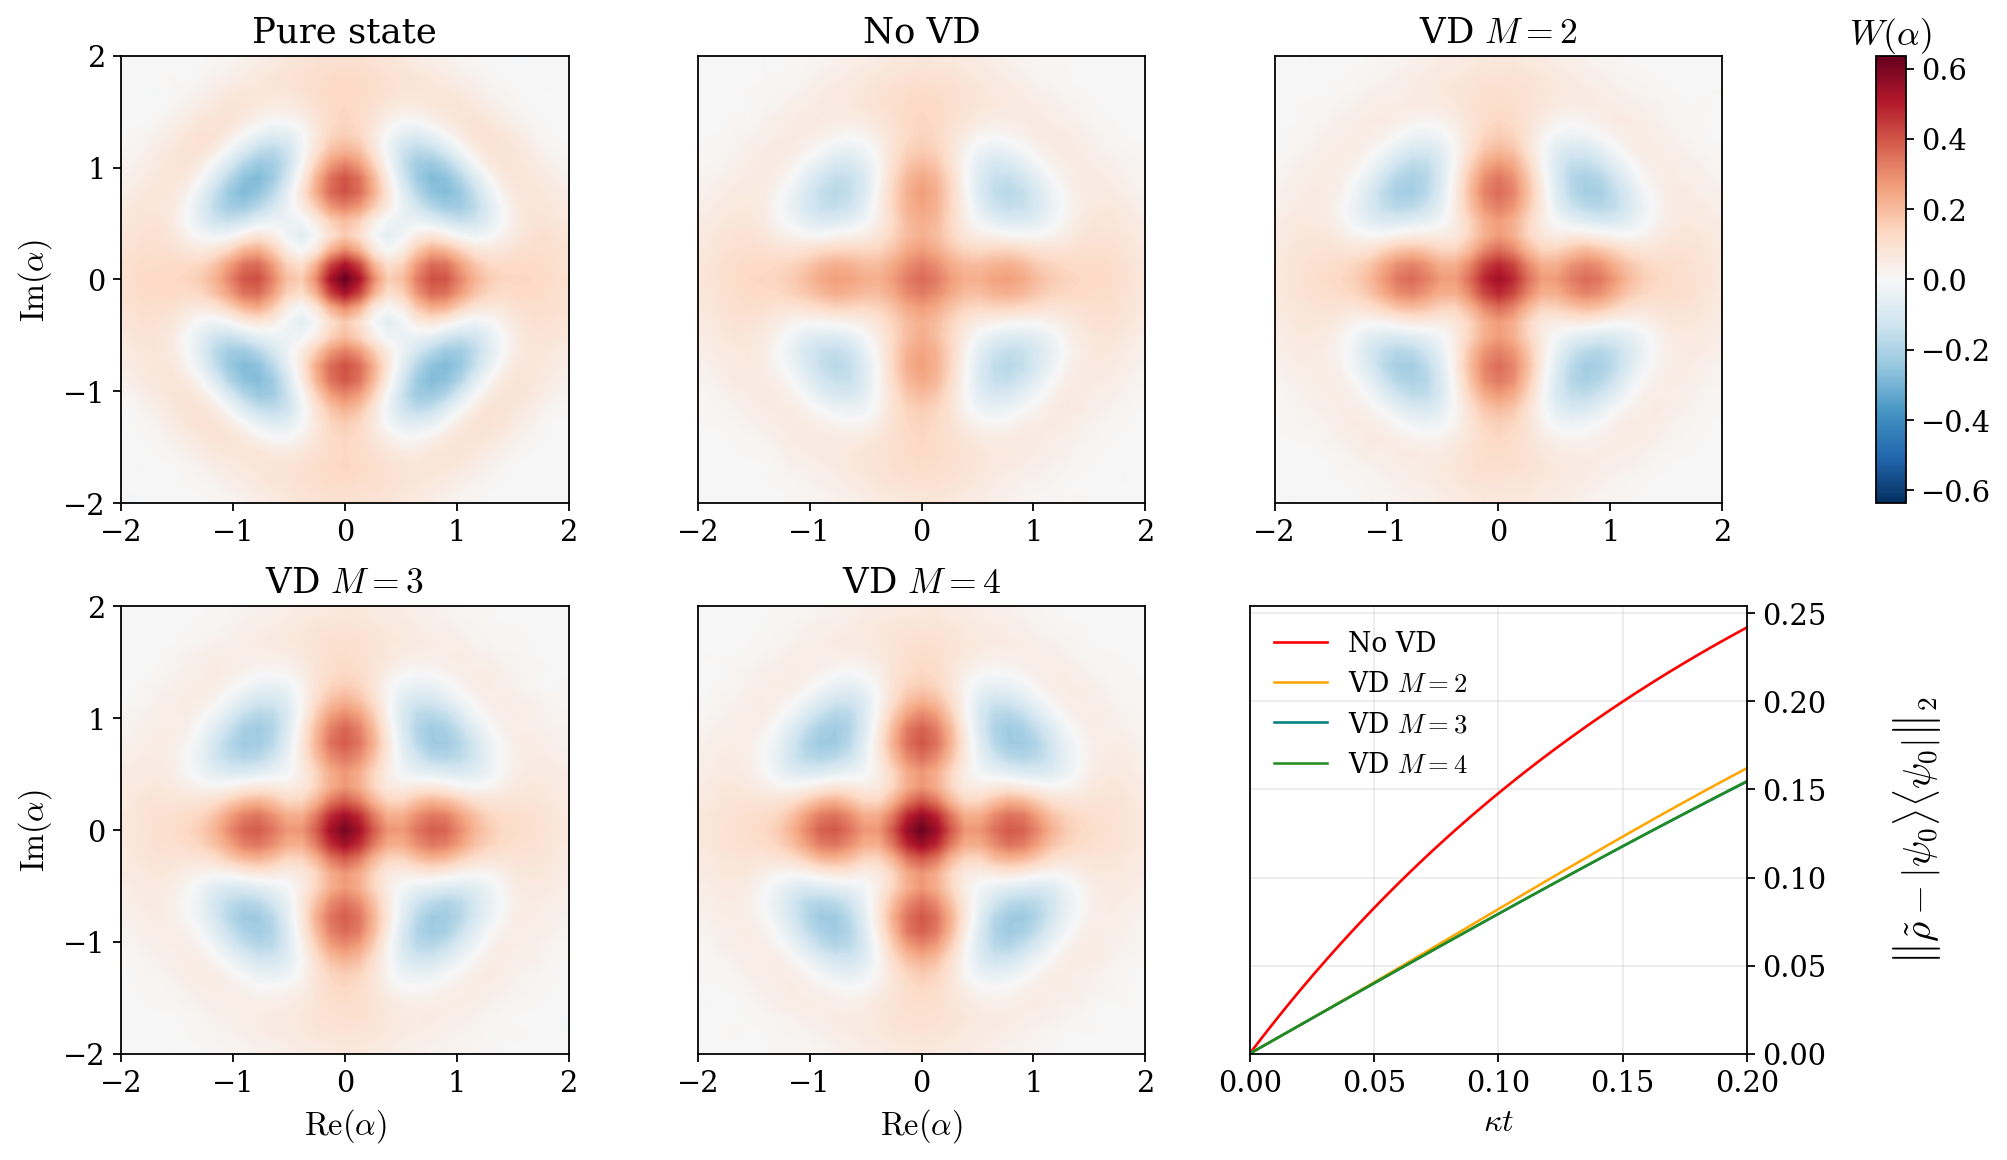

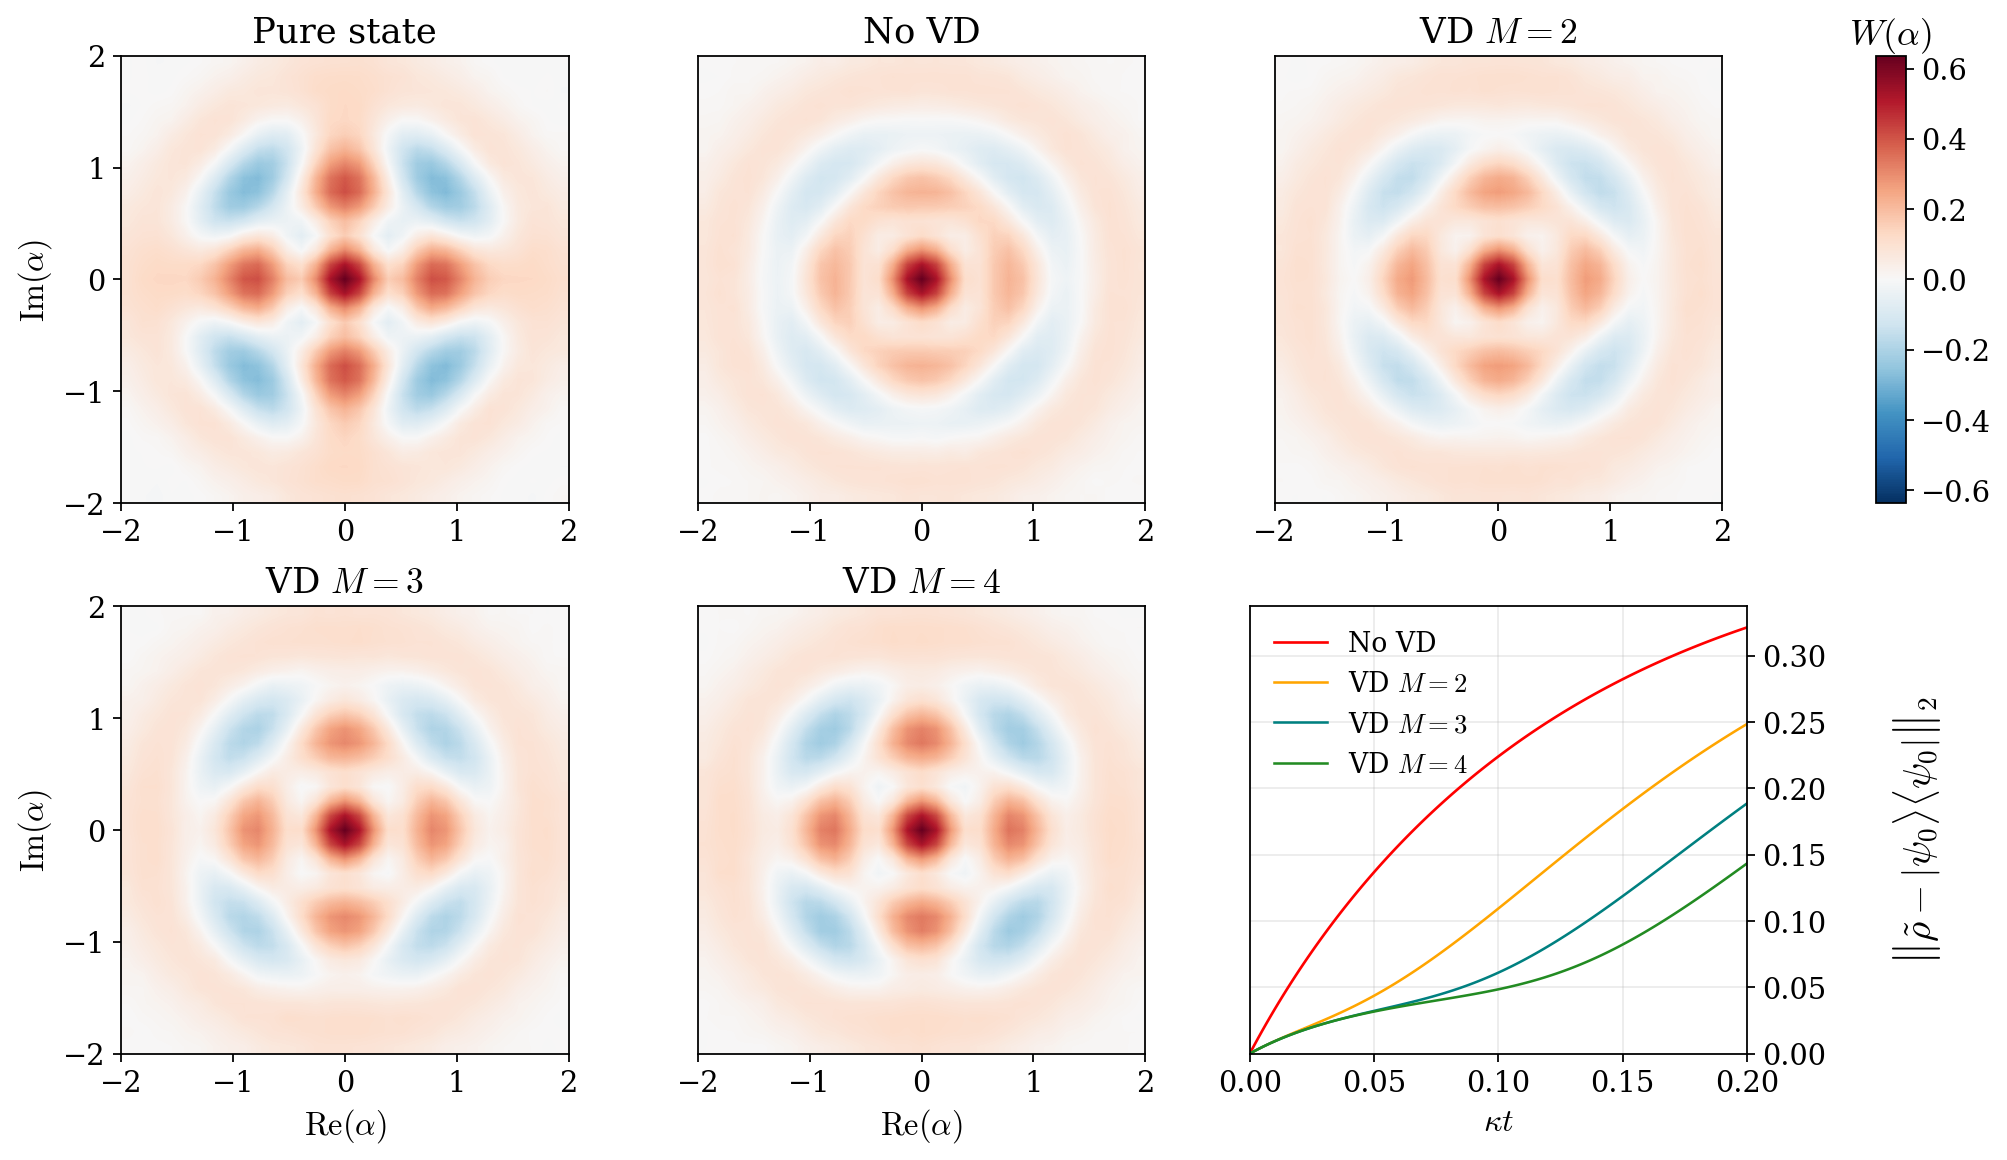

{('even_cat',
  'loss'): {'scenario_labels': ['Pure state',
   'No VD',
   'VD $M=2$',
   'VD $M=3$',
   'VD $M=4$'], 'noise_note': 'loss snapshot: $t=50.0$, $\\eta=0.819$', 'point_count': 961, 'grid_shape': (31,
   31), 'dx': 0.13333333333333333, 'dy': 0.13333333333333333, 'cell_area': 0.017777777777777778},
 ('even_cat',
  'dephasing'): {'scenario_labels': ['Pure state',
   'No VD',
   'VD $M=2$',
   'VD $M=3$',
   'VD $M=4$'], 'noise_note': 'dephasing snapshot: $t=50.0$, $\\gamma t=0.200$', 'point_count': 961, 'grid_shape': (31,
   31), 'dx': 0.13333333333333333, 'dy': 0.13333333333333333, 'cell_area': 0.017777777777777778},
 ('square_cat',
  'loss'): {'scenario_labels': ['Pure state',
   'No VD',
   'VD $M=2$',
   'VD $M=3$',
   'VD $M=4$'], 'noise_note': 'loss snapshot: $t=50.0$, $\\eta=0.819$', 'point_count': 961, 'grid_shape': (31,
   31), 'dx': 0.13333333333333333, 'dy': 0.13333333333333333, 'cell_area': 0.017777777777777778},
 ('square_cat',
  'dephasing'): {'scenario_labels':

In [12]:
cat_wigner_jobs = [
    ('even_cat', 'loss', PAPER_PLOT_CONFIG['seed_base'] + 111, 'even_cat_wigner_loss.pdf'),
    ('even_cat', 'dephasing', PAPER_PLOT_CONFIG['seed_base'] + 221, 'even_cat_wigner_dephasing.pdf'),
    ('square_cat', 'loss', PAPER_PLOT_CONFIG['seed_base'] + 161, 'square_cat_wigner_loss.pdf'),
    ('square_cat', 'dephasing', PAPER_PLOT_CONFIG['seed_base'] + 281, 'square_cat_wigner_dephasing.pdf'),
]

cat_wigner_info = {}
for state_key, noise_kind, seed, filename in cat_wigner_jobs:
    fig, axes, info = create_sampled_wigner_paper_figure(
        states[state_key]['rho'],
        states[state_key]['title'],
        PAPER_PLOT_CONFIG['copies_list'],
        PAPER_PLOT_CONFIG['snapshot_time'],
        PAPER_PLOT_CONFIG['times'],
        PAPER_PLOT_CONFIG['kappa'],
        noise_kind=noise_kind,
        x_values=paper_x_values,
        y_values=paper_y_values,
        shots=PAPER_PLOT_CONFIG['shots'],
        seed=seed,
    )
    cat_wigner_info[(state_key, noise_kind)] = info
    output_figure(fig, filename)
    plt.close(fig)

cat_wigner_info

## Even, tri, and square cat parity

This comparison tracks the parity expectation $\langle (-1)^{\hat n}\rangle$ under photon loss. The horizontal axis is the dimensionless noise strength $\kappa t$. The even and square cats are the states defined above, and the three-component cat is

$$
|C_3(\alpha)\rangle \propto |\alpha\rangle + |\omega\alpha\rangle + |\omega^2\alpha\rangle,
\qquad \omega=e^{2\pi i/3}.
$$

The red curve is the noisy state without virtual distillation. The marker series show sampled parity estimates after replacing the noisy state by $\rho^M/\mathrm{Tr}(\rho^M)$ for each VD order.

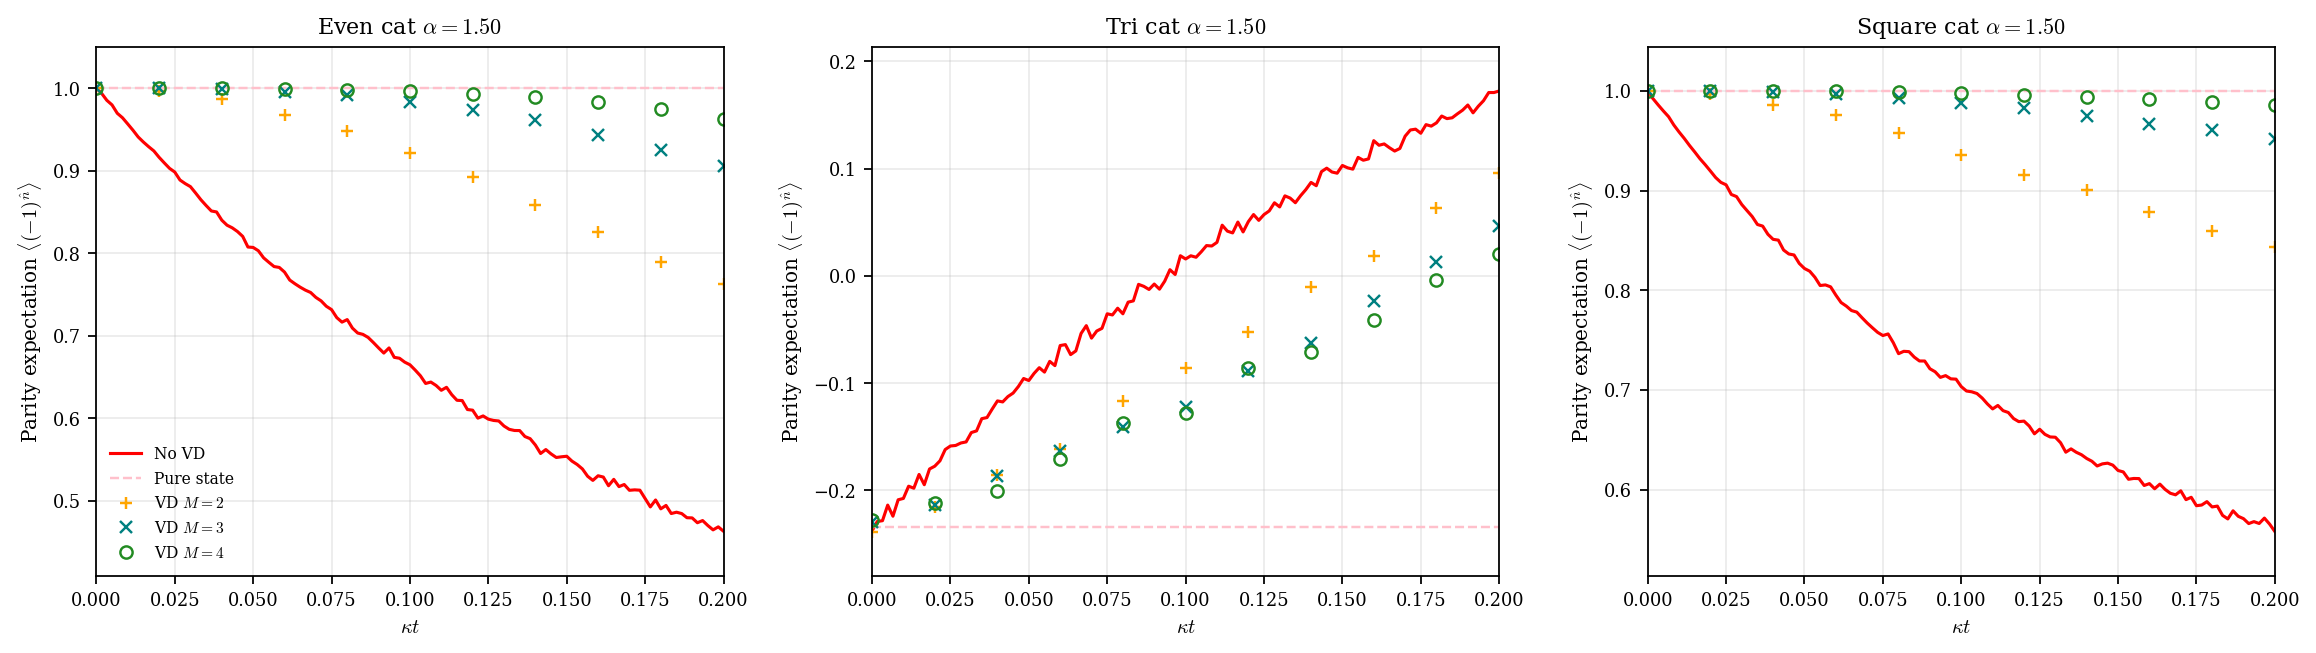

In [13]:
fig, axes, parity_data = create_zoomed_sampled_parity_state_list_figure(
    [
        (states['even_cat']['title'], states['even_cat']['rho']),
        (states['tri_cat']['title'], states['tri_cat']['rho']),
        (states['square_cat']['title'], states['square_cat']['rho']),
    ],
    PAPER_PLOT_CONFIG['copies_list'],
    PAPER_PLOT_CONFIG['times'],
    PAPER_PLOT_CONFIG['vd_times'],
    PAPER_PLOT_CONFIG['kappa'],
    noise_kind='loss',
    shots=PAPER_PLOT_CONFIG['shots'],
    seed=PAPER_PLOT_CONFIG['seed_base'] + 43,
    figsize=(14.6, 4.2),
)
output_figure(fig, 'cat_parity_loss.pdf')
plt.close(fig)

## Fock `|3>` Wigner grid, 3x3 layout

This figure repeats the displaced-parity Wigner reconstruction for the number state

$$
\rho_0 = |3\rangle\langle 3|.
$$

Fock-state Wigner functions have alternating positive and negative radial structure. The comparison shows `Pure state`, `No VD`, `VD M=2`, `VD M=3`, `VD M=4`, and the phase-space $L^2$ error curve.

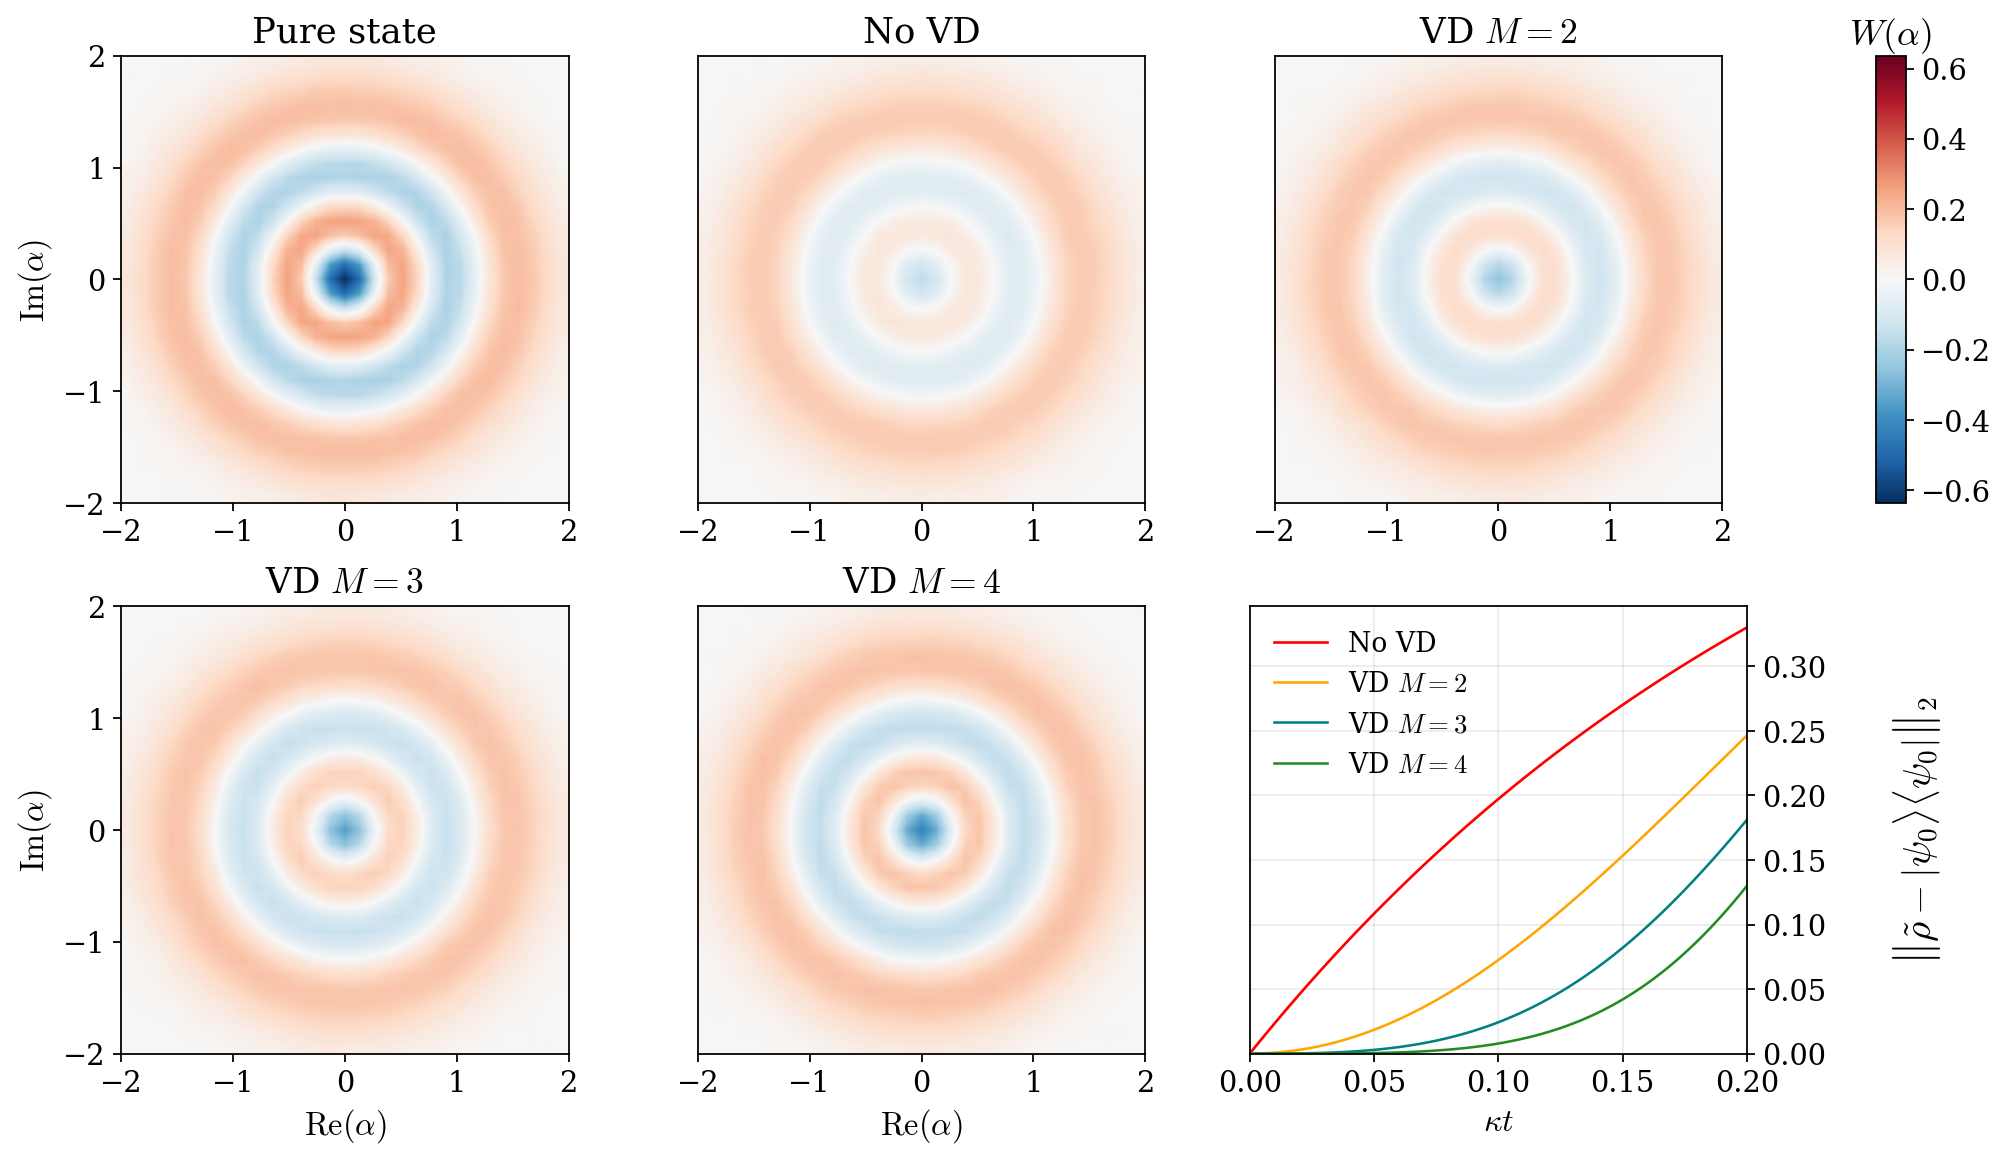

{'scenario_labels': ['Pure state',
  'No VD',
  'VD $M=2$',
  'VD $M=3$',
  'VD $M=4$'],
 'noise_note': 'loss snapshot: $t=50.0$, $\\eta=0.819$',
 'point_count': 961,
 'grid_shape': (31, 31),
 'dx': 0.13333333333333333,
 'dy': 0.13333333333333333,
 'cell_area': 0.017777777777777778}

In [14]:
fig, axes, fock_wigner_info = create_sampled_wigner_paper_figure(
    states['fock3']['rho'],
    states['fock3']['title'],
    PAPER_PLOT_CONFIG['copies_list'],
    PAPER_PLOT_CONFIG['snapshot_time'],
    PAPER_PLOT_CONFIG['times'],
    PAPER_PLOT_CONFIG['kappa'],
    noise_kind='loss',
    x_values=paper_fock_x_values,
    y_values=paper_fock_y_values,
    shots=PAPER_PLOT_CONFIG['shots'],
    seed=PAPER_PLOT_CONFIG['seed_base'] + 181,
)
output_figure(fig, 'fock3_wigner_loss.pdf')
plt.close(fig)
fock_wigner_info

## N00N characteristic-function maps

The final example uses a two-mode N00N state,

$$
|\mathrm{N00N}_N\rangle = \frac{|N,0\rangle + |0,N\rangle}{\sqrt{2}}, \quad N=4.
$$

The plotted quantity is the squared magnitude of the joint number characteristic function,

$$
|\chi(\phi_a,\phi_b)|^2,
\qquad
\chi(\phi_a,\phi_b)=\sum_{m,n}p_{m,n}e^{i(m\phi_a+n\phi_b)}.
$$

The generated figure uses photon-loss data with the `RdBu_r` color palette.

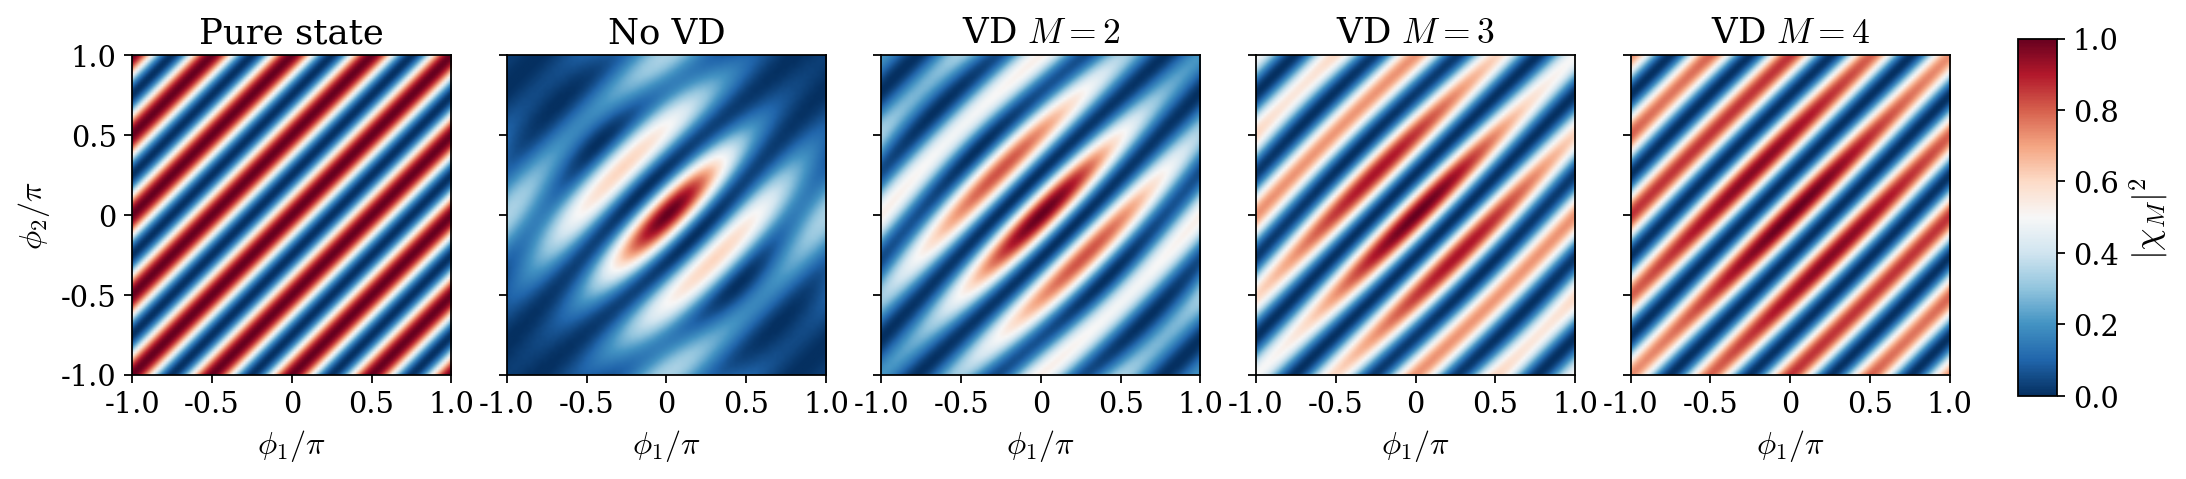

{'RdBu_r': 'loss snapshot: $t=50.0$, $\\eta=0.819$'}

In [15]:
noon_characteristic_data = {}
for cmap in ['RdBu_r']:
    fig, axes, data = plot_noon_characteristic_modsq_snapshot(
        n=NOON_CHARACTERISTIC_GRID_CONFIG['n'],
        dim=NOON_CHARACTERISTIC_GRID_CONFIG['dim'],
        copies_list=PHASE_RECONSTRUCTION_CONFIG['copies_list'],
        snapshot_time=PHASE_RECONSTRUCTION_CONFIG['snapshot_time'],
        kappa=COMMON_PLOT_CONFIG['kappa'],
        phase_points=NOON_CHARACTERISTIC_GRID_CONFIG['phase_points'],
        noise_kind='loss',
        cmap=cmap,
        figsize=NOON_CHARACTERISTIC_GRID_CONFIG['figsize'],
    )
    noon_characteristic_data[cmap] = data
    output_figure(fig, f'noon_characteristic_loss_{cmap}.pdf')
    plt.close(fig)

{cmap: data['noise_note'] for cmap, data in noon_characteristic_data.items()}